# First try on Gaussian Processes SF/N&NN-MF # 

In this notebook we attempt to reproduce the numerical experiments presented in the article "A Non-Nested Infilling Strategy for Multi-Fidelity based Efficient Global Optimization" of Sacher et al. (2021)

In [1]:
# Some useful libraries for data analysis and plotting
import numpy as np
import matplotlib.pyplot as plt
from adri_plotstyle import init_plot_style
init_plot_style()

✅ Matplotlib LaTeX style initialisé (Police: helvet, Taille: 12)


### 1) Gernerating a toy dataset ###

We shall first generate a toy dataset based on a Hartmann function (2D or 6D) in which we will introduce some nose/bias.

In [2]:

def Hartmann6D(x):
    """
    Hartmann 6D function.

    Parameters
    ----------
    x : array-like, shape (6,)
        Input point in 6D space.

    Returns
    -------
    float
        Function value at the input point.
    """
    alpha = [1.0, 1.2, 3.0, 3.2]
    A = [[10.0, 3.0, 17.0, 3.5, 1.7, 8.0],
         [0.05, 10.0, 17.0, 0.1, 8.0, 14.0],
         [3.0, 3.5, 1.7, 10.0, 17.0, 8.0],
         [17.0, 8.0, 0.05, 10.0, 14.0, 3.5]]
    P = [[1312, 1696, 5569, 1244, 8283, 5886],
         [2329, 4135, 8307, 3736, 1004, 9991],
         [2348, 1451, 3522, 2883, 3047, 6650],
         [4047, 8828, 8732, 5743, 1091, 381]]

    x = np.asarray(x)
    if x.shape != (6,):
        raise ValueError("Input must be a point in R^6.")

    total = sum(alpha[i] * np.exp(-sum(A[i][j] * (x[j] - P[i][j] / 10000) ** 2 for j in range(6))) for i in range(4))
    
    return -total

In [3]:
# defining a multi-fidelity Hartmann approximation function
def f_l(x, deg=6, k=1, delta=0.1):
    if deg not in [6]:
        raise ValueError("deg must be either 2 or 6.")

    if k == np.inf or k is None:
        return Hartmann6D(x)

    u_0 = -5.0 if deg == 6 else -7.0
    if k == 0:
        return u_0

    delta_x_k = (delta / k) * np.ones(deg)
    x_shifted = np.array(x) + delta_x_k

    f_true = Hartmann6D(x_shifted)

    u_prev = u_0
    for _ in range(int(k)):
        u_prev = 0.5 * ((f_true**2) / u_prev + u_prev)

    return u_prev



(-3.0, 0.5)

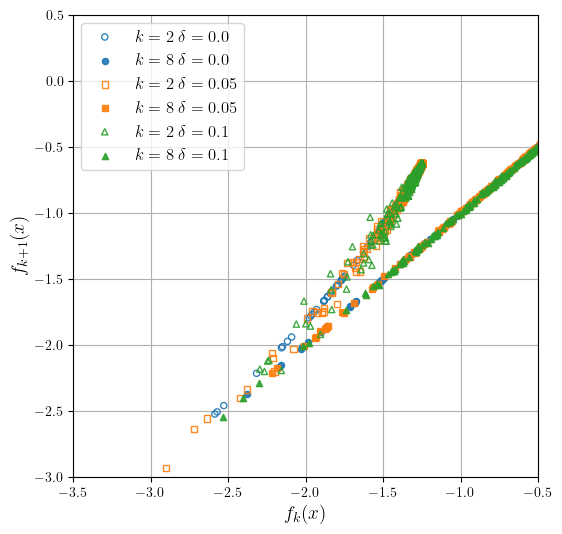

In [4]:

Delta = [0.00, 0.05, 0.10]
N_iter = 1000
Degree = 6
ks = [2, 8]

markers = ["o", "s", "^"]
colors = ["C0", "C1", "C2"]  # on color per delta 

plt.figure(figsize=(6, 6))
plt.grid(True, zorder=1)

for idx, delta in enumerate(Delta):
    marker = markers[idx]
    color = colors[idx]
    for k in ks:
        fk = []
        fk1 = []
        for i in range(N_iter):
            x = np.random.rand(Degree)
            f_k = f_l(x, deg=Degree, k=k, delta=delta)
            f_k_plus_1 = f_l(x, deg=Degree, k=k + 1, delta=delta)
            fk.append(f_k)
            fk1.append(f_k_plus_1)

        fc = "none" if k == 2 else color

        plt.scatter(
            fk,
            fk1,
            alpha=0.9,
            label=f"$k={k}\ \delta = {delta}$",
            s=20,
            zorder=2,
            marker=marker,
            facecolors=fc,
            edgecolors=color,
        )

plt.legend()
plt.xlabel("$f_{k}(x)$", fontsize=14)
plt.ylabel("$f_{k+1}(x)$", fontsize=14)
plt.xlim([-3.5, -0.5])
plt.ylim([-3.0, 0.5])



### 2) Constructing de GP algorithms ###

#### 2.1) First constructing a SF-EGO (Surrogate model) ####

As the article suggests, we create a LHS of 20 pts to do the training on.

In [5]:
from scipy.stats import qmc

# n=20 pts, Dimension=6
dimension = 6
n_points = 20

# LHS init
sampler = qmc.LatinHypercube(d=dimension, seed=42)

# pts between 0 and 1
X = sampler.random(n=n_points)

print("X shape:", X.shape)

# we then evaluate the Hartmann function at a very high level of finelity (namely k=8) and delta = 0.05
Y = np.array([f_l(x, deg=Degree, k=8, delta=0.05) for x in X])

print("Y shape:", Y.shape)

X shape: (20, 6)
Y shape: (20,)


In [6]:
# defining the single fidelity surrogate approach to finding the global minimum of the Hartmann function

def Cov_fct(x, y, l, t1, t2):
    """
    Covariance function for Gaussian Process.

    Parameters
    ----------
    x : array-like, shape (n_samples_x, n_features)
        Input samples.
    y : array-like, shape (n_samples_y, n_features)
        Input samples.
    l : float
        Length scale parameter.
    t1 : float
        Signal variance parameter.
    t2 : float
        Noise variance parameter.


    Returns
    -------
    cov : float 
        Covariance between x and y.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    l = np.asarray(l)

    if x.ndim == 1:
        x = x.reshape(1, -1)
    if y.ndim == 1:
        y = y.reshape(1, -1)
    if l.ndim == 0:
        l = np.full(x.shape[1], l)
    if x.shape[1] != y.shape[1] != l.shape[0]:
        raise ValueError("Input samples must have the same number of features.")

    cov = t1
    for i in range(x.shape[0]):
        dist = x[0][i] - y[0][i]
        cov *= np.exp(-(dist**2)/(2 * l[i]**2))

    return cov + t2

In [7]:
# Covariance Matrix function 

def C_Mtx(X, l, t1, t2):
    """
    Covariance matrix function for Gaussian Process.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input samples.
    l : float
        Length scale parameter.
    t1 : float
        Signal variance parameter.  
    t2 : float
        Noise variance parameter.

    Returns
    -------
    C : array-like, shape (n_samples, n_samples)
        Covariance matrix.
    """
    C = np.zeros((X.shape[0], X.shape[0]))
    for i in range(X.shape[0]):
        for j in range(X.shape[0]):
            C[i, j] = Cov_fct(X[i], X[j], l, t1, t2)
    return C

### Initialization test of hperparameters ###

In [8]:
#Random initialization of hyperparameters
l = np.random.rand(Degree)  # length scale
t1 = 0.1  # signal variance
t2 = 0.1  # noise variance

sigma_epsilon = 1e-6  # noise variance for the observations

C = C_Mtx(X, l, t1, t2)
K = C + sigma_epsilon**2 * np.eye(n_points)  # Add noise variance to the diagonal
print("Covariance matrix K shape:", K.shape)

Covariance matrix K shape: (20, 20)


### Log likelyhood : we adapt Eq.15 of the article to the case of SF ###

$$\mathcal{L} = -\frac{n}{2} \log(2\pi) - \frac{1}{2} \log\vert{}K\vert{} - \frac{1}{2} Y^T K^{-1} Y$$

In [9]:
import scipy.linalg

def log_likelihood(Y, K):
    """
    Compute the log-likelihood of the Gaussian Process.

    Parameters
    ----------
    Y : array-like, shape (n_samples,)
        Observed values.
    K : array-like, shape (n_samples, n_samples)
        Covariance matrix.

    Returns
    -------
    float
        Log-likelihood value.
    """
    n = len(Y)
    Y = Y.reshape(-1, 1)
    
    try:
        #Cholesky (K = L * L^T) because we had issues with np.linalg showing some instabilities
        L, lower = scipy.linalg.cho_factor(K, lower=True)
    except scipy.linalg.LinAlgError:
        return -1e10
    
    # 2. solve for K * alpha = Y (Replace K^-1 @ Y)
    alpha = scipy.linalg.cho_solve((L, lower), Y)

    logdet = 2.0 * np.sum(np.log(np.diag(L)))
    
    # exact formula
    ll = -0.5 * n * np.log(2 * np.pi) - 0.5 * logdet - 0.5 * (Y.T @ alpha)
    
    return ll.item()

We then implemenmt a simple gradient ascent and also use a scitlearn optimizer to find optimal hyperparameters.
But first, lets express the gradient analytically.
$$\frac{\partial \mathcal{L}}{\partial \theta} = \frac{1}{2} Y^T K^{-1} \frac{\partial K}{\partial \theta} K^{-1} Y - \frac{1}{2} \text{Tr}\left(K^{-1} \frac{\partial K}{\partial \theta}\right)$$

But we use $\alpha = K^{-1} Y$, which results in: $$\frac{\partial \mathcal{L}}{\partial \theta} = \frac{1}{2} \text{Tr}\left( (\alpha \alpha^T - K^{-1}) \frac{\partial K}{\partial \theta} \right)$$

Then decomposing the partial derivatives: $$\frac{\partial K}{\partial \sigma_{ \epsilon }^2} = I_n $$

$$\frac{\partial K}{\partial \theta_1} = \exp\left( - \sum_{k=1}^d \frac{(x_{i,k} - x_{j,k})^2}{2l_k^2} \right)$$

$$\frac{\partial K_{i,j}}{\partial l_m} = C_{i,j}^{\text{no biais}} \times \frac{(x_{i,m} - x_{j,m})^2}{l_m^3}$$


In [10]:
# eventually we didn't use so much this function since the direct computing of 
# the gradient showed som numerical problems and could't lead to a good convergence 

def compute_log_likelihood_gradient(X, Y, K, theta1, theta2, l_vectors, sigma2_e):
    """Computes the gradient of the marginal log-likelihood.

    X : array of shape (n, d) - Input training points
    Y : array of shape (n, 1) or (n,) - Training targets
    K : array of shape (n, n) - Precomputed total covariance matrix
    """
    n, d = X.shape

    # more robust Colesky
    L, lower = scipy.linalg.cho_factor(K, lower=True)
    
    # alpha = K^-1 @ Y
    alpha = scipy.linalg.cho_solve((L, lower), Y)
    alpha = alpha.reshape(-1, 1)
    
    # K_inv = K^-1 @ Identité (more stable than np.linalg.inv)
    K_inv = scipy.linalg.cho_solve((L, lower), np.eye(n))
    
    # Core matrix W = (alpha @ alpha.T - K_inv)
    W = alpha @ alpha.T - K_inv
    
    # here we for W to be perfectly symmetric
    W = 0.5 * (W + W.T)

    # 2. Compute the partial derivatives components of the C matrix
    # Matrix to store squared distances per dimension
    dist_sq_m = np.zeros((n, n, d))
    sum_dist = np.zeros((n, n))

    for m in range(d):
        # Coordinate difference for dimension m between all pairs (i, j) using broadcasting
        diff_m = X[:, m : m + 1] - X[:, m].reshape(1, -1)
        dist_sq_m[:, :, m] = diff_m**2
        sum_dist += dist_sq_m[:, :, m] / (2 * l_vectors[m] ** 2)

    # Exponential component and unbiased C matrix
    exp_component = np.exp(-sum_dist)
    C_unbiased = theta1 * exp_component

    # 3. Compute gradients of K with respect to each hyperparameter
    # Gradient for sigma_epsilon^2 (Trace of W * I_n)
    grad_sigma2 = 0.5 * np.trace(W)

    # Gradient for theta2 (Trace of W * Matrix of 1s)
    # np.sum(W) is mathematically equivalent to np.trace(W @ np.ones((n,n))) but faster
    grad_theta2 = 0.5 * np.sum(W)

    # Gradient for theta1
    dK_dtheta1 = exp_component
    grad_theta1 = 0.5 * np.trace(W @ dK_dtheta1)

    # Gradient for each length scale l_m
    grad_l = np.zeros(d)
    for m in range(d):
        dK_dlm = C_unbiased * (dist_sq_m[:, :, m] / (l_vectors[m] ** 3))
        grad_l[m] = 0.5 * np.trace(W @ dK_dlm)

    # Return gradients as a structured dictionary
    return {
        "sigma2_eps": grad_sigma2,
        "theta2": grad_theta2,
        "theta1": grad_theta1,
        "l_lengths": grad_l,
    }


In [11]:
def gradient_ascent(X, Y, l_init, t1_init, t2_init, sigma2_e_init, learning_rate=0.01, n_iterations=1000):
    """
    Perform gradient ascent to optimize hyperparameters of the Gaussian Process.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input samples.
    Y : array-like, shape (n_samples,)
        Observed values.
    l_init : array-like, shape (n_features,)
        Initial length scale parameters.
    t1_init : float
        Initial signal variance parameter.
    t2_init : float
        Initial noise variance parameter.
    sigma2_e_init : float
        Initial noise variance for the observations.
    learning_rate : float
        Learning rate for gradient ascent.
    n_iterations : int
        Number of iterations for optimization.

    Returns
    -------
    dict
        Optimized hyperparameters and log-likelihood history.
    """
    l = np.copy(l_init)
    t1 = t1_init
    t2 = t2_init
    sigma2_e = sigma2_e_init

    log_likelihood_history = []

    for iteration in range(n_iterations):
        # Compute covariance matrix K with current hyperparameters
        C = C_Mtx(X, l, t1, t2)
        K = C + sigma2_e * np.eye(X.shape[0])

        # Compute log-likelihood
        ll = log_likelihood(Y, K)
        log_likelihood_history.append(ll)

        if iteration % 100 == 0 or iteration == n_iterations - 1:
            l_str = np.array2string(l, precision=4, suppress_small=True)
            print(f"Iter {iteration:4d}: LL = {ll:10.4f} | l = {l_str} | t1 = {t1:.4f} | t2 = {t2:.4f} | sig2 = {sigma2_e:.4f}")

        # Compute gradients
        gradients = compute_log_likelihood_gradient(X, Y, K, t1, t2, l, sigma2_e)
        grad_norm = np.sqrt(gradients["sigma2_eps"]**2 + gradients["theta1"]**2 + gradients["theta2"]**2 + np.sum(gradients["l_lengths"]**2))

        if grad_norm < 1e-5:
            print(f"Gradient norm is very small ({grad_norm}) at iteration {iteration}. Stopping optimization.")
            break

        # Update hyperparameters using gradient ascent
        clip_val = 5.0 
        g_sig2 = np.clip(gradients["sigma2_eps"], -clip_val, clip_val)
        g_t1   = np.clip(gradients["theta1"], -clip_val, clip_val)
        g_t2   = np.clip(gradients["theta2"], -clip_val, clip_val)
        g_l    = np.clip(gradients["l_lengths"], -clip_val, clip_val)

        sigma2_e += learning_rate * g_sig2
        t1 += learning_rate * g_t1
        t2 += learning_rate * g_t2
        l += learning_rate * g_l

        # Ensure hyperparameters remain positive
        sigma2_e = max(sigma2_e, 1e-6)
        t1 = max(t1, 1e-6)
        t2 = max(t2, 1e-6)
        l = np.maximum(l, 1e-6)


    return {
        "l": l,
        "t1": t1,
        "t2": t2,
        "sigma2_e":sigma2_e,
        "log_likelihood_history": log_likelihood_history,
    }

In [12]:
# First test run of the gradient ascent optimization
l_init = np.random.rand(Degree)  # Random initialization of length scales
t1_init = 0.1  # Initial signal variance
t2_init = 0.1  # Initial noise variance
sigma2_e_init = 1e-6  # Initial noise variance for the observations 

X_test = X
Y_test = Y

Y_mean = np.mean(Y_test)
Y_std = np.std(Y_test)
Y_norm = (Y_test - Y_mean) / Y_std

gradient_ascent_results = gradient_ascent(X_test, Y_norm, l_init, t1_init, t2_init, sigma2_e_init, learning_rate=5e-5, n_iterations=3000)



Iter    0: LL = -8589532.4780 | l = [0.9239 0.6752 0.3468 0.2509 0.8401 0.4676] | t1 = 0.1000 | t2 = 0.1000 | sig2 = 0.0000


Iter  100: LL =  -371.0880 | l = [0.9489 0.7002 0.3218 0.2759 0.8151 0.4926] | t1 = 0.1250 | t2 = 0.1250 | sig2 = 0.0250
Iter  200: LL =  -187.3243 | l = [0.9739 0.7252 0.2968 0.3009 0.7901 0.5176] | t1 = 0.1500 | t2 = 0.1357 | sig2 = 0.0500
Iter  300: LL =  -126.6498 | l = [0.9989 0.7502 0.2718 0.3259 0.7702 0.5426] | t1 = 0.1750 | t2 = 0.1354 | sig2 = 0.0750
Iter  400: LL =   -96.8679 | l = [1.0239 0.7752 0.2579 0.3509 0.7829 0.5676] | t1 = 0.2000 | t2 = 0.1320 | sig2 = 0.1000
Iter  500: LL =   -79.3901 | l = [1.0489 0.8002 0.2591 0.3759 0.7974 0.5926] | t1 = 0.2250 | t2 = 0.1275 | sig2 = 0.1250
Iter  600: LL =   -68.0182 | l = [1.0739 0.8252 0.2602 0.4009 0.8094 0.6176] | t1 = 0.2500 | t2 = 0.1226 | sig2 = 0.1500
Iter  700: LL =   -60.1034 | l = [1.0989 0.8502 0.2611 0.4259 0.8194 0.6426] | t1 = 0.2750 | t2 = 0.1174 | sig2 = 0.1750
Iter  800: LL =   -54.3270 | l = [1.1239 0.8752 0.2619 0.4509 0.8281 0.6676] | t1 = 0.3000 | t2 = 0.1122 | sig2 = 0.2000
Iter  900: LL =   -49.9607 | l =

In [13]:
from scipy.optimize import minimize

Y_mean = np.mean(Y_test)
Y_std = np.std(Y_test)
Y_norm = (Y_test - Y_mean) / Y_std

def objective_for_scipy_no_grad(params, X, Y):
    d = X.shape[1]
    l_vectors = params[0:d]
    t1 = params[d]
    t2 = params[d+1]
    sigma2_e = params[d+2]
    
    C = C_Mtx(X, l_vectors, t1, t2)
    K = C + sigma2_e * np.eye(X.shape[0])
    
    ll = log_likelihood(Y, K)
    return -ll  

# parameters to optimize as a vector
d = X_test.shape[1]
initial_params = np.zeros(d + 3)
initial_params[0:d] = 0.5  # l_vectors 
initial_params[d] = 1.0    # t1 
initial_params[d+1] = 1e-4 # t2 
initial_params[d+2] = 0.01 # sigma2_e 

# bonds of search for the parameters 
bounds = []
for i in range(d):
    bounds.append((0.01, 10.0))

bounds.append((0.1, 5.0))
bounds.append((1e-6, 1.0))
bounds.append((1e-6, 1e-2))

# SciPy optimization Loop
print("Start of optimisatuion...")
result = minimize(
    fun=objective_for_scipy_no_grad,
    x0=initial_params,
    args=(X_test, Y_norm),
    method='L-BFGS-B',
    jac=False,       # we let Scipy compute the gradient 
    bounds=bounds,
    options={'disp': True, 'maxiter': 1000}
)

# Final parameters after optimisation
best_params = result.x
print("\nEnd of optimisation !")
print(f"Best Log-Likelihood : {-result.fun:.4f}")
print(f"best l    = {best_params[0:d]}")
print(f"best t1   = {best_params[d]:.4f}")
print(f"best t2   = {best_params[d+1]:.4f}")
print(f"best sig2 = {best_params[d+2]:.4f}")

Start of optimisatuion...
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            9     M =           10

At X0         1 variables are exactly at the bounds

At iterate    0    f=  8.49158D+02    |proj g|=  2.62467D+00

At iterate    1    f=  3.47241D+01    |proj g|=  9.98683D+00

At iterate    2    f=  3.43249D+01    |proj g|=  1.49583D+00

At iterate    3    f=  3.35530D+01    |proj g|=  9.98072D+00
  ys=-1.474E+00  -gs= 5.538E-01 BFGS update SKIPPED

At iterate    4    f=  3.34712D+01    |proj g|=  1.67019D+00

At iterate    5    f=  3.34541D+01    |proj g|=  1.73922D+00

At iterate    6    f=  3.33617D+01    |proj g|=  7.26109D+00

At iterate    7    f=  3.25668D+01    |proj g|=  9.99000D+00

At iterate    8    f=  2.82933D+01    |proj g|=  5.87520D+00

At iterate    9    f=  2.82931D+01    |proj g|=  4.91491D+00

At iterate   10    f=  2.82906D+01    |proj g|=  2.75463D+00

At iterate   11    f=  2.82904D+01    |proj g|=  2.27452D-03

At iterate

The gradient ascent algorithm is verry likely being blocked on a local maximum. This is why we will implement the AEI 
### AEI ###

We first start by finding the minimal value of Y 

In [14]:
# showing the minimal value of Y and corresponding X
i_min = np.argmin(Y)
print("Y_min = ",Y[i_min]," corresponding to X = ", X[i_min] )

Y_min =  -0.7181017589032505  corresponding to X =  [0.82214839 0.41080509 0.96678432 0.22968066 0.05929898 0.84165135]


In [15]:
# we implement a function that will make the predictions for a new point 
def predict_gp(x_new, X, Y, l, t1, t2, sigma2_e):
    n_points = X.shape[0]
    kappa = Cov_fct(x_new, x_new, l, t1, t2)

    C_current = C_Mtx(X, l, t1, t2)
    k_vec = np.ones(n_points)

    for i in range(n_points):
        k_vec[i]=Cov_fct(x_new, X[i], l, t1, t2)

    f_hat      = k_vec.T @ np.linalg.inv( (C_current + sigma2_e * np.eye(n_points))) @ Y
    sigma2_hat = kappa + sigma2_e - k_vec.T @ np.linalg.inv( (C_current + sigma2_e * np.eye(n_points))) @ k_vec

    return {
        "f_hat": f_hat,
        "sigma2_hat": sigma2_hat 
    }

def compute_u(f_hat, sigma_hat, f_best):
    # avoid divizion by 0 if sigma is null
    sigma_hat = np.maximum(sigma_hat, 1e-10)
    return (f_best - f_hat) / sigma_hat

from scipy.stats import norm

def expected_improvement(f_hat, sigma2_hat, f_best):
    """
    Compute classical EI
    """
    sigma_hat = np.sqrt(np.maximum(sigma2_hat, 1e-10))
    u = compute_u(f_hat, sigma_hat, f_best)
    
    ei = sigma_hat * (u * norm.cdf(u) + norm.pdf(u))
    return ei

def augmented_expected_improvement(x_new, X_train, Y_train, f_best, best_params):
    d = X_train.shape[1]
    l = best_params[0:d]
    t1 = best_params[d]
    t2 = best_params[d+1]
    sigma2_e = best_params[d+2]
    sigma_e = np.sqrt(max(sigma2_e, 1e-12))
    
    # get the predictions of the GP
    pred = predict_gp(x_new, X_train, Y_train, l, t1, t2, sigma2_e)
    f_hat = pred["f_hat"]
    sigma2_hat = pred["sigma2_hat"]
    
    # sigma > 0
    sigma2_hat = np.maximum(sigma2_hat, 1e-10)
    sigma_hat = np.sqrt(sigma2_hat)
    
    # Calcul de l'EI
    ei = expected_improvement(f_hat, sigma2_hat, f_best)
    
    # penalizty factor in AEI with additional security
    denominator = np.sqrt(sigma2_hat + sigma2_e)
    if denominator == 0:
        penalty = 0.0
    else:
        penalty = 1.0 - (sigma_e / denominator)
    
    # making sure that the penality remins bounded between 0 and 1
    penalty = np.clip(penalty, 0.0, 1.0)
    
    aei = ei * penalty
    return aei.item() if hasattr(aei, 'item') else aei


Training loop

In [16]:
def find_next_point(X_train, Y_train, f_best, best_params, bounds):
    best_aei = -float('inf')
    best_x = None
    
    d = X_train.shape[1]
    
    
    for _ in range(20):
        x0 = np.random.uniform(bounds[:, 0], bounds[:, 1], size=d)
        
        # Comme SciPy minimise, on minimise l'opposé de l'AEI (-AEI)
        res = minimize(
            fun=lambda x: -augmented_expected_improvement(x.reshape(1, -1), X_train, Y_train, f_best, best_params),
            x0=x0,
            method='L-BFGS-B',
            bounds=bounds
        )
        
        # On cherche le score AEI le plus haut (donc le -res.fun le plus bas)
        current_aei = -res.fun
        if current_aei > best_aei:
            best_aei = current_aei
            best_x = res.x
            
    return best_x

## Efficient Global Optimisation (EGO) in the SF case ##

In [17]:
# bounds 
d = X_test.shape[1]
bounds_gp = []
for i in range(d):
    bounds_gp.append((0.01, 10.0))  # longueurs l
bounds_gp.append((0.1, 5.0))        # t1
bounds_gp.append((1e-6, 1.0))       # t2
bounds_gp.append((1e-6, 1e-2))      # sigma2_e

bounds_aei = [(0, 1)] * d
# -----------------------------------------------------------------                        

n_steps = 1

for step in range(n_steps):
    print(f"\n--- Itération {step + 1} / {n_steps} ---")
    
    # first we nned to find f_best
    f_best = np.min(Y_norm)
    d = X_test.shape[1]
    bounds = [(0, 1)] * d
    

    # find best candidate via multistart on AEI
    best_aei = -float('inf')
    best_x = None
    
    #----------------------- AEI steps ----------------------------
    for _ in range(100):
        x0 = np.random.uniform(0, 1, size=d)
        res = minimize(
            fun=lambda x: -augmented_expected_improvement(
                x_new=x.reshape(1, -1), 
                X_train=X_test, 
                Y_train=Y_norm, 
                f_best=f_best, 
                best_params=best_params
            ),
            x0=x0,
            method='L-BFGS-B',
            bounds=bounds
        )
        current_aei = -res.fun
        if current_aei > best_aei:
            best_aei = current_aei
            best_x = res.x
            
    print(f"optimal point selected (x_star) : {best_x}")
    
    #----------- Evaluation of Hartmann after AEI -------------------
    y_new = Hartmann6D(best_x) 
    print(f"Hartmann fct value : {y_new}")
    

    X_test = np.vstack((X_test, best_x))
    Y_test = np.append(Y_test, y_new)
    
    Y_mean = np.mean(Y_test)
    Y_std = np.std(Y_test)
    Y_norm = (Y_test - Y_mean) / Y_std
    
    #--------------- GA to get the new hyperparameters ---------------
    res_gp = minimize(
        fun=objective_for_scipy_no_grad,
        x0=best_params,
        args=(X_test, Y_norm),
        method='L-BFGS-B',
        bounds=bounds_gp, 
        options={'maxiter': 500}
    )
    best_params = res_gp.x
    print(f"uploaded GP. New Log-Likelihood : {-res_gp.fun:.4f}")
    print(f"best corrent Y (non normalized) : {np.min(Y_test):.6f}")


--- Itération 1 / 1 ---
optimal point selected (x_star) : [0.82659039 0.90857837 0.85936171 0.74940749 0.86102136 0.57711843]
Hartmann fct value : -0.0002288625503783632
uploaded GP. New Log-Likelihood : -42.8751
best corrent Y (non normalized) : -0.718102


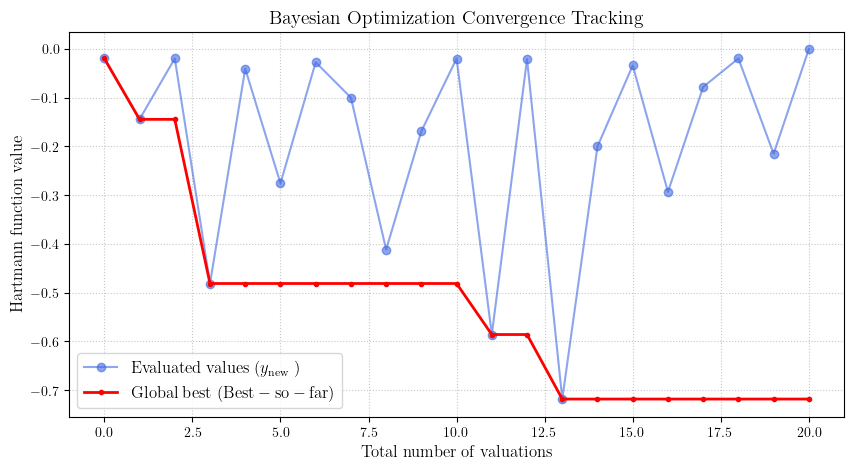

In [18]:

# Compute cumulative minimum (the best y found so far)
best_so_far = np.minimum.accumulate(Y_test)

plt.figure(figsize=(10, 5))
plt.plot(range(len(Y_test)), Y_test, 'o-', color='royalblue', alpha=0.6, label='$\mathrm{Evaluated\ values\ } (y_{\mathrm{new}}\ \mathrm{})$')
plt.plot(range(len(Y_test)), best_so_far, 'r.-', linewidth=2, label='$\mathrm{Global\ best\ (Best-so-far)}$')
plt.xlabel("$\mathrm{Total\ number\ of\ valuations}$")
plt.ylabel("$\mathrm{Hartmann\ function\ value}$")
plt.title("$\mathrm{Bayesian\ Optimization\ Convergence\ Tracking}$")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

As we see we do not reach the expected global minimum of -3.32 of the 6d Hartmann function. This was expected since the single fidelity algorithm is more a proof of concept than an actual efficient case of study. Nevertheless this was a forst approach to a EGO (Efficient Global Optimisation) algorithm. We saw that the GP has been implemented in a surrogate way, avoiding coutless calls to the Hartmann function. Of course here, the total cost of the Hartmann6D function is lower than the AEI impelementation but in a more costly case, this might be one of the only efficient ways of finding global extremas to a function.

## 2.2) N-MF GP ##
We will now implement the first muty fidelity algorithm. for now it will be nested but it is the first step towards a more efficient way of finding a reliable global 
binimum to our function. As we saw previously, with the SF algorithm, we could only find rapidly what appears to bo a local minima. We will generelize the case to N levels of fidelity to ease the understanding of the system for later on. Since we have the opportunity to use ase many levels of fidelity with our Hartmann function we will do so.

Quick reminder: Nested (N) means $X_N \subset X_{N-1} \subset \dots \subset X_1$

In [19]:

from scipy.stats import qmc

def generate_nested_lhs(d, n_levels_points):
    """
    Generates nested Latin Hypercube Sampling (LHS) designs for N levels of fidelity.
    Each higher fidelity level's points are a subset of the previous lower fidelity level.
    
    Parameters:
    - d: int, dimension of the input space (e.g., 6 for Hartmann 6D)
    - n_levels_points: list of int, number of points for each level from lowest to highest 
                       [n_1, n_2, ..., n_N], where n_1 > n_2 > ... > n_N
                       
    Returns:
    - X_levels: list of numpy arrays, containing the design points for each fidelity level.
    """
    # Use scipy's LatinHypercube to generate the largest set first (Level 1)
    sampler = qmc.LatinHypercube(d=d, seed=42)
    max_points = n_levels_points[0]
    base_sample = sampler.random(n=max_points)
    
    X_levels = []
    # Sort or select nested subsets from the base sample
    # For a strictly nested design, Level k is a prefix subset of Level k-1
    for n_pts in n_levels_points:
        # Take the first n_pts from the base Latin Hypercube sample to preserve space-filling properties
        X_sub = base_sample[:n_pts, :]
        X_levels.append(X_sub)
        
    return X_levels

# Example usage for 3 levels of fidelity (e.g., 50 points for LF1, 20 for LF2, 5 for HF)
d = 6
n_levels_points = [50, 20, 5]
X_nested = generate_nested_lhs(d, n_levels_points)

# Display the sizes to verify nesting structure
for i, x_lvl in enumerate(X_nested):
    print(f"Level {i+1} fidelity points shape: {x_lvl.shape}")

Level 1 fidelity points shape: (50, 6)
Level 2 fidelity points shape: (20, 6)
Level 3 fidelity points shape: (5, 6)


By definition $$ Y^{(l)}(\mathbf{x}) =  \rho_{(l-1)}Y^{(l-1)}(\mathbf{x})+ \delta Y^{(l)}(\mathbf{x}), \ \ Y^{(0)}(\mathbf{x}) = 0$$ 

Where $ \rho_{(l-1)} $ accounts for the correlation between the two successive levels and $\delta Y^{(l)}(\mathbf{x})$ is an indiependent GP accounting for the error between this level and the previous one: $(l-1)$.
we also have the definition of the vector of noisy observations residual:
$$ \Delta Y^{(l)}(\rho_{(l-1)}) = \left\{
    \begin{array}{ll}
        Y^{(l)} &  \ \ l=1 \\
        Y^{(l)}-\rho_{(l-1)}Y^{(l-1)}_{\rightarrow (l)}. &  \ \ l\geq 1
    \end{array}
\right. $$

In [20]:
def Delta_Y_l(Y_l, Y_l_minus_1, rho_l_minus_1):
    """
    Computes the residuals for multi-fidelity Gaussian Process modeling.
    
    Parameters:
    - Y_l: numpy array, observations at fidelity level l
    - Y_l_minus_1: numpy array, observations at fidelity level l-1
    - rho_l_minus_1: float, correlation coefficient between levels l and l-1
    
    Returns:
    - Delta_Y: numpy array, residuals for level l
    """
    if Y_l_minus_1 is None or rho_l_minus_1 is None:
        return Y_l  
    # ----------------------------------------
    
    if len(Y_l) != len(Y_l_minus_1):
        raise ValueError("Y_l and Y_l_minus_1 must have the same length.")
        
    return Y_l - rho_l_minus_1 * Y_l_minus_1

We then add on the covariance with different fidelity levels. 
$$C^{(l)}(x, x', \mathbf{\Theta}) = \text{cov}\left(Y^{(l)}(x), Y^{(l)}(x')\right) = \sum_{j=1}^{l} \left( \prod_{i=j}^{l-1} \rho_i^2 \right) C_j\left(x, x'; \Theta_{(j)}\right)$$

In [21]:
def nested_mf_covariance(x, y, Theta, rho_l , fidelity_level):
    """
    Computes the covariance between two points x and y for a multi-fidelity Gaussian Process.
    
    Parameters:
    - x: numpy array, point in the input space
    - y: numpy array, point in the input space
    - length: numpy array, length scales for each dimension
    - t1: float, signal variance
    - t2: float, noise variance
    - rho_l: float, correlation coefficient for level l
    - level: int, fidelity level (1 for lowest fidelity)
    
    Returns:
    - cov: float, covariance value between x and y at the specified fidelity level
    """
    n_params = len(x)

    Sum_corr = 0.0
    for j in range(fidelity_level):

        rho_2_i = 1
        for i in range(j,fidelity_level-1):
            rho_2_i *= rho_l[i]**2
            
        Sum_corr += rho_2_i * Cov_fct(x, y, Theta[j][0:n_params], Theta[j][n_params], Theta[j][n_params+1])

    return Sum_corr

In [22]:
# we also implement a function to compute the covariance matrix for a given level of fidelity
def nested_mf_covariance_matrix(X, Theta, rho_l, fidelity_level):
    """
    Computes the covariance matrix for a set of points X at a given fidelity level.
    
    Parameters:
    - X: numpy array, shape (n_samples, n_features), input points
    - Theta: list of tuples, each containing (length scales, t1, t2) for each fidelity level
    - rho_l: list of floats, correlation coefficients for each fidelity level
    - fidelity_level: int, the fidelity level for which to compute the covariance matrix
    
    Returns:
    - C: numpy array, shape (n_samples, n_samples), covariance matrix at the specified fidelity level
    """
    n_samples = X.shape[0]
    C = np.zeros((n_samples, n_samples))
    
    for i in range(n_samples):
        for j in range(n_samples):
            C[i, j] = nested_mf_covariance(X[i], X[j], Theta, rho_l, fidelity_level)
    
    return C

We must also implement the new log likely hood:

$$ \mathcal{L}\left(\rho^{(l-1)}, \Theta^{(l)}, \sigma_{\varepsilon(l)}^2\right) = -\frac{n^{(l)}}{2}\log(2\pi) - \frac{1}{2}\log\left\vert{}\mathbf{C}^{(l)}\left(\Theta^{(l)}\right) + \sigma_{\varepsilon(l)}^2 \mathbf{I}_{n^{(l)}}\right\vert{} - \frac{1}{2} \Delta Y^{(l)\top} \left( \mathbf{C}^{(l)}\left(\Theta^{(l)}\right) + \sigma_{\varepsilon(l)}^2 \mathbf{I}_{n^{(l)}} \right)^{-1} \Delta Y^{(l)} $$




In [23]:
def base_covariance_matrix(X, Theta_l):
    """
    Calcule la matrice de covariance standard (non cumulée) 
    pour le GP d'écart du niveau courant.
    """
    n = len(X)
    C = np.zeros((n, n))
    d = X.shape[1]
    
    # On gère l'extraction selon que vous optimisiez t1/t2 ou non
    lengthscales = Theta_l[0:d]
    t1 = Theta_l[d] if len(Theta_l) > d else 1.0
    t2 = Theta_l[d+1] if len(Theta_l) > d+1 else 1.0
    
    for i in range(n):
        for j in range(n):
            C[i, j] = Cov_fct(X[i], X[j], lengthscales, t1, t2)
    return C

# def log_likelihood_mf(rho_l_minus1, Theta_l, sigma_epsilon_l, X_l, Y_l, Y_l_minus_1, fidelity_level):
#     """
#     Computes the log-likelihood for a multi-fidelity Gaussian Process at a given fidelity level.

#     Parameters:
#     - rho_l_minus1: float, correlation coefficient between levels l and l-1
#     - Theta_l: list, parameters for the covariance function at level l
#     - sigma_epsilon_l: float, noise variance at level l
#     - X_l: numpy array, input points at level l
#     - Y_l: numpy array, observed values at level l
#     - Y_l_minus_1: numpy array, observed values at level l-1
#     - fidelity_level: int, the fidelity level for which to compute the log-likelihood

#     Returns
#     -------
#     float
#         Log-likelihood value.
#     """
#     # Compute the residuals for level l 

#     Delta_Y_l_val = Delta_Y_l(Y_l, Y_l_minus_1, rho_l_minus1)
    
#     # --- CORRECTION : avoid a None ---
#     rho_list = [] if rho_l_minus1 is None else [rho_l_minus1]
    
#     # Compute the covariance matrix for level l
#     C_l = nested_mf_covariance_matrix(X_l, Theta_l, rho_list, fidelity_level)

#     # Compute the covariance matrix for level l
#     C_l = nested_mf_covariance_matrix(X_l, Theta_l, [rho_l_minus1], fidelity_level)
#     K_l = C_l + sigma_epsilon_l * np.eye(len(X_l))
#     determinant = np.linalg.det(K)
#     if determinant <= 0:
#         return -np.inf  # Log-likelihood is undefined for non-positive definite covariance matrices
#     n_l = len(X_l)
#     log_det_K = np.log(determinant)
#     term1 = -0.5 * n_l * np.log(2 * np.pi)
#     term2 = -0.5 * log_det_K
#     term3 = -0.5 * Delta_Y_l_val.T @ np.linalg.inv(K_l) @ Delta_Y_l_val
#     log_likelihood_value = term1 + term2 + term3
#     return log_likelihood_value

def log_likelihood_mf(rho_l_minus1, Theta_l, sigma_epsilon_l, X_l, Y_l, Y_l_minus_1, fidelity_level):
    """
    Équation 15 : Log-vraisemblance marginale des résidus.
    """
    # 1. Calcul des résidus
    Delta_Y_l_val = Delta_Y_l(Y_l, Y_l_minus_1, rho_l_minus1)
    
    # 2. CORRECTION : Matrice de covariance du GP d'écart (pas la cumulative !)
    C_l = base_covariance_matrix(X_l, Theta_l)
    
    # 3. Ajout du bruit sur la diagonale
    K_l = C_l + sigma_epsilon_l * np.eye(len(X_l))
    
    # 4. Calcul de la vraisemblance marginale classique
    try:
        # Utilisation de la décomposition de Cholesky pour la stabilité numérique
        L_chol = np.linalg.cholesky(K_l)
        log_det = 2.0 * np.sum(np.log(np.diag(L_chol)))
        
        # Résolution de K_l * alpha = Delta_Y_l_val
        alpha = np.linalg.solve(L_chol.T, np.linalg.solve(L_chol, Delta_Y_l_val))
        
        # -1/2 * Y^T * K^-1 * Y - 1/2 * log|K| - n/2 * log(2pi)
        n = len(X_l)
        log_lik = -0.5 * np.dot(Delta_Y_l_val, alpha) - 0.5 * log_det - 0.5 * n * np.log(2 * np.pi)
        return log_lik
    except np.linalg.LinAlgError:
        # Pénalité si la matrice est mal conditionnée
        return -1e10

We need to evaluate the new predicted average $\hat{f}_l(x)$ and variance $\hat{\sigma}_l^2(x)$ defined as: 
$$\hat{f}_l(x) = \rho_{l-1} \hat{f}_{l-1}(x) + \mathbf{k}_l(x)^\top \left( \mathbf{C}^{(l)} \right)^{-1} \Delta Y^{(l)}$$
and:
$$\hat{\sigma}_l^2(x) = \rho_{l-1}^2 \hat{\sigma}_{l-1}^2(x) + \sigma_l^2 k_l(x, x) - \mathbf{k}_l(x)^\top \left( \mathbf{C}^{(l)} \right)^{-1} \mathbf{k}_l(x)$$

In [24]:
def k_l_vector(new_x, X_vector, Theta, rho_l, fidelity_level):
    """
    Computes the covariance vector between a new point and a set of existing points for a given fidelity level.

    Parameters
    ----------
    new_x : array-like, shape (n_features,)
        New input point.
    X_vector : array-like, shape (n_samples, n_features)
        Existing input points.
    Theta : list of tuples
        Each tuple contains (length scales, t1, t2) for each fidelity level.
    rho_l : list of floats
        Correlation coefficients for each fidelity level.
    fidelity_level : int
        The fidelity level for which to compute the covariance vector.

    Returns
    -------
    k_vector : array-like, shape (n_samples,)
        Covariance vector between new_x and each point in X_vector at the specified fidelity level.
    """
    n_samples = X_vector.shape[0]
    k_vector = np.zeros(n_samples)

    for i in range(n_samples):
        k_vector[i] = nested_mf_covariance(new_x, X_vector[i], Theta, rho_l, fidelity_level)

    return k_vector

In [25]:
# Problems of matrix inversion might still occur. For a more robust implementation, consider using Cholesky decomposition or other 
# numerical techniques to avoid direct inversion of the covariance matrix.
import numpy as np

# Note : l'utilisation de np.linalg.solve() est mathématiquement équivalente à 
# np.linalg.inv() mais beaucoup plus stable numériquement pour les Processus Gaussiens.
def predictions_mf(f_l_minus_1, sigma_l_minus_1, new_x, X_l, Y_l, Y_l_minus_1, Theta, rho_l_minus_1, sigma_epsilon_l, fidelity_level):
    """
    Computes the predicted mean and variance for a new point in a multi-fidelity Gaussian Process.
    """
    # 1. Compute the covariance matrix for existing points
    C_l = nested_mf_covariance_matrix(X_l, Theta, rho_l_minus_1, fidelity_level)
    K_l = C_l + sigma_epsilon_l * np.eye(len(X_l))

    # 2. Compute the covariance vector between new_x and existing points
    k_vector = k_l_vector(new_x, X_l, Theta, rho_l_minus_1, fidelity_level)
    kappa = nested_mf_covariance(new_x, new_x, Theta, rho_l_minus_1, fidelity_level)

    # 3. Residuals
    delta_Y_l_val = Delta_Y_l(Y_l, Y_l_minus_1, rho_l_minus_1)
    
    # --- CORRECTIONS MATHÉMATIQUES ICI ---
    K_l_inv = np.linalg.inv(K_l)
    
    # Prédiction propre au GP d'écart (discrepancy) du niveau l
    delta_hat = k_vector.T @ K_l_inv @ delta_Y_l_val
    var_gp_l = kappa - (k_vector.T @ K_l_inv @ k_vector)
    
    # L'algorithme EGO peut parfois produire des variances légèrement négatives à 
    # cause des approximations numériques, on s'assure qu'elle reste positive.
    var_gp_l = max(var_gp_l.item() if hasattr(var_gp_l, 'item') else var_gp_l, 1e-12)

    # Prédiction multi-fidélité récursive (Correction du * en +)
    f_hat = (rho_l_minus_1 * f_l_minus_1) + delta_hat
    
    # Variance multi-fidélité récursive (Correction de la formule)
    sigma2_hat = (rho_l_minus_1**2 * sigma_l_minus_1**2) + var_gp_l
    
    return {
        "f_hat": f_hat,
        "sigma2_hat": sigma2_hat,
        "var_gp_l": var_gp_l  # <- INDISPENSABLE pour la Merit Function (eq 25) !
    }

In [26]:

from scipy.stats import norm

def expected_improvement(f_hat, sigma2_hat, f_best):
    """
    Compute classical EI

    Parameters
    ----------
    f_hat : float   
        Predicted mean at the new point.
    sigma2_hat : float  
        Predicted variance at the new point.
    f_best : float
        Best observed value.    

    Returns
    -------
    float   
        Expected Improvement (EI) value.    
    """
    sigma_hat = np.sqrt(np.maximum(sigma2_hat, 1e-10))
    
    u = (f_best - f_hat) / sigma_hat 
    ei = sigma_hat * (u * norm.cdf(u) + norm.pdf(u))
    return ei

def aei_multi_fidelity(f_hat_L, sigma2_hat_L, f_best_L, sigma2_e_L):
    """
    Compute the Augmented Expected Improvement (AEI) for multi-fidelity Gaussian Process.

    Parameters
    ----------
    f_hat_L : float 
        Predicted mean at fidelity level L.
    sigma2_hat_L : float    
        Predicted variance at fidelity level L.
    f_best_L : float
        Best observed value at fidelity level L.
    sigma2_e_L : float
        Noise variance at fidelity level L. 

    Returns
    -------
    float   
        Augmented Expected Improvement (AEI) value.
    """
    sigma_e_L = np.sqrt(max(sigma2_e_L, 1e-12))
    sigma2_hat_L = np.maximum(sigma2_hat_L, 1e-10)
    
    # EI
    ei = expected_improvement(f_hat_L, sigma2_hat_L, f_best_L)
    
    # AEI : EI penalized by the uncertainty of the model
    denominator = np.sqrt(sigma2_hat_L + sigma2_e_L)
    penalty = 0.0 if denominator == 0 else 1.0 - (sigma_e_L / denominator)
    penalty = np.clip(penalty, 0.0, 1.0)
    
    return (ei * penalty).item() if hasattr(ei * penalty, 'item') else (ei * penalty)

We will now consgtruct the merit function:
$$M_{N-MF}(x, l) = AEI^{(L)}(x) \times \left( \frac{\sum_{l' \le L} W(l')}{\sum_{l' \le l} W(l')} \right) \times \max \left(0, \frac{\sum_{l'=1}^{l} R_{l'}^2 \Delta \hat{\sigma}_{(l')}^2(x\vert{}x, l')}{\hat{\sigma}_{(L)}^2(x)} \right)$$


In [27]:
def merit_nested(x, l_candidate, L, costs, f_best_L, sigma2_e_L, rhos, noise_lp, gp_variances_at_x, f_hat_L, sigma2_hat_L):
    """
    Compute the merit function for a candidate point in a multi-fidelity Gaussian Process.

    Parameters
    ----------
    x : array-like  
        Candidate point in the input space.
    l_candidate : int
        Fidelity level of the candidate point.
    L : int
        Highest fidelity level.
    costs : list of floats
        Costs associated with each fidelity level.
    f_best_L : float
        Best observed value at fidelity level L.
    sigma2_e_L : float  
        Noise variance at fidelity level L.
    rhos : list of floats   
        Correlation coefficients between fidelity levels.  
    noise_lp : float
        Noise variance at fidelity level lp.
    gp_variances_at_x : list of floats  
        Predicted variances at the candidate point for each fidelity level.
    f_hat_L : float
        Predicted mean at fidelity level L. 
    sigma2_hat_L : float
        Predicted variance at fidelity level L. 

    Returns
    ------- 
    float
        Merit value for the candidate point.    
    """
    
    aei_L = aei_multi_fidelity(f_hat_L, sigma2_hat_L, f_best_L, sigma2_e_L)
    
    if aei_L <= 0:
        return 0.0 
    
  
    cost_total_L = sum(costs) 
    cost_total_l_candidate = sum(costs[:l_candidate])
    cost_ratio = cost_total_L / cost_total_l_candidate
    
    
    variance_reduction_sum = 0.0
    
    for lp in range(1, l_candidate + 1):
        idx = lp - 1 
        
        var_gp_lp = gp_variances_at_x[idx] 
        

        delta_sigma2_lp = (var_gp_lp ** 2) / (var_gp_lp + noise_lp)
        
    
        R2_lp = 1.0
        if lp < L:
            for i in range(lp, L):
                R2_lp *= (rhos[i-1] ** 2)
                
        
        variance_reduction_sum += R2_lp * delta_sigma2_lp
        
    
    information_ratio = max(0.0, variance_reduction_sum / max(sigma2_hat_L, 1e-12))
    
    
    merit = aei_L * cost_ratio * information_ratio
    return merit

We now have all the bricks to proceed with the EGO alogorithm in the N-MF case. 

### EGO algorithm ###

In [28]:


def extract_subpart_vector(X_higher, X_lower, Y_lower, tol=1e-6):
    """
    Extracts the observation values from the lower fidelity dataset (Y_lower)
    that correspond exactly to the spatial coordinates in X_higher.
    
    Arguments:
    - X_higher: numpy array of shape (n_higher, d), points at level l
    - X_lower: numpy array of shape (n_lower, d), points at level l-1
    - Y_lower: numpy array of shape (n_lower,), observations at level l-1
    - tol: float, distance tolerance for floating-point comparisons
    
    Returns:
    - subpart_Y: numpy array of shape (n_higher,) containing the matching Y values.
    """
    subpart_Y = np.zeros(X_higher.shape[0])
    
    for i, x in enumerate(X_higher):
        # Calculate the Euclidean distance between x and all points in X_lower
        distances = np.linalg.norm(X_lower - x, axis=1)
        
        # Find the index of the closest point
        closest_idx = np.argmin(distances)
        
        # Ensure the point is actually the same (distance is close to 0)
        if distances[closest_idx] < tol:
            subpart_Y[i] = Y_lower[closest_idx]
        else:
            raise ValueError(f"Point {x} from higher fidelity not found in lower fidelity dataset. Nested property violated.")
            
    return subpart_Y

def is_already_evaluated(x, X_train_level, tol=1e-6):
    """
    Checks if a point x is already present in the dataset X_train_level.
    
    Arguments:
    - x: numpy array of shape (d,), the point to check
    - X_train_level: numpy array of shape (n, d), the existing dataset for a specific level
    - tol: float, distance tolerance
    
    Returns:
    - True if the point is already in the dataset, False otherwise.
    """
    if X_train_level.shape[0] == 0:
        return False
        
    distances = np.linalg.norm(X_train_level - x, axis=1)
    return np.min(distances) < tol

def predict_base_gp(x_new, X_train, Y_train, Theta_l, sigma_epsilon_l):
    """
    Krigeage standard : Prédit la moyenne et la variance d'un GP d'écart 
    au niveau l, en utilisant sa propre matrice de covariance.
    """
    # 1. Matrice de covariance du GP
    C = base_covariance_matrix(X_train, Theta_l)
    K = C + sigma_epsilon_l * np.eye(len(X_train))
    K_inv = np.linalg.inv(K)

    # 2. Vecteur de covariance k
    d = X_train.shape[1]
    lengthscales = Theta_l[0:d]
    t1 = Theta_l[d] if len(Theta_l) > d else 1.0
    t2 = Theta_l[d+1] if len(Theta_l) > d+1 else 1.0

    k_vec = np.zeros(len(X_train))
    for i in range(len(X_train)):
        k_vec[i] = Cov_fct(x_new, X_train[i], lengthscales, t1, t2)

    # 3. Variance locale kappa
    kappa = Cov_fct(x_new, x_new, lengthscales, t1, t2)

    # 4. Prédictions
    delta_hat = k_vec.T @ K_inv @ Y_train
    
    # La variance peut être très légèrement négative à cause de l'inversion numérique
    sigma2_delta = kappa - (k_vec.T @ K_inv @ k_vec)
    
    # On gère l'extraction propre (array 1D vers scalaire) et la limite positive
    delta_hat_scalar = delta_hat.item() if hasattr(delta_hat, 'item') else delta_hat
    sigma2_delta_scalar = max(sigma2_delta.item() if hasattr(sigma2_delta, 'item') else sigma2_delta, 1e-12)

    return delta_hat_scalar, sigma2_delta_scalar

def predict_nested_mf(x_new, thetas, rhos, noises, X_train, Y_train):
    """
    Recursively computes the mean and variance of the Multi-Fidelity model at the highest level L,
    and extracts the variance of each individual discrepancy GP for the merit function.
    
    Arguments:
    - x_new: the point where we want to predict
    - thetas: list of hyperparameters for each level [theta_1, ..., theta_L]
    - rhos: list of scaling factors [rho_1, ..., rho_{L-1}]
    - noises: list of optimized noise variances [sigma2_e_1, ..., sigma2_e_L]
    - X_train, Y_train: dictionaries containing the nested datasets
    
    Returns:
    - f_hat_prev: final predicted mean at level L
    - sigma2_hat_prev: final predictive variance at level L
    - gp_variances_at_x: list of predictive variances for each independent GP [var_GP1, ..., var_GPL]
    """
    L = len(thetas)
    
    f_hat_prev = 0.0
    sigma2_hat_prev = 0.0
    gp_variances_at_x = []
    
    for l in range(1, L + 1):
        X_l = X_train[l]
        Y_l = Y_train[l]
        theta_l = thetas[l-1]
        noise_l = noises[l-1]
        
        # 1. Prepare the target vector for the GP at level l
        if l == 1:
            target_Y = Y_l
        else:
            rho_prev = rhos[l-2]
            Y_l_minus_1 = extract_subpart_vector(X_l, X_train[l-1], Y_train[l-1])
            target_Y = Y_l - rho_prev * Y_l_minus_1
            
        # 2. VRAIE PRÉDICTION : Remplacement des placeholders !
        delta_hat, sigma2_delta = predict_base_gp(x_new, X_l, target_Y, theta_l, noise_l)
        
        # Store the variance of this specific GP
        gp_variances_at_x.append(sigma2_delta)
        
        # 3. Apply the recursive formulation
        if l == 1:
            f_hat_current = delta_hat
            sigma2_hat_current = sigma2_delta
        else:
            rho_prev = rhos[l-2]
            f_hat_current = rho_prev * f_hat_prev + delta_hat
            sigma2_hat_current = (rho_prev ** 2) * sigma2_hat_prev + sigma2_delta
            
        # Update for the next iteration (move up the hierarchy)
        f_hat_prev = f_hat_current
        sigma2_hat_prev = sigma2_hat_current
        
    return f_hat_prev, sigma2_hat_prev, gp_variances_at_x

In [29]:
# the two optimisation algorithms
from scipy.optimize import minimize
from scipy.optimize import differential_evolution

def run_nested_mf_ego(X_train, Y_train, L, costs, bounds, n_iterations, true_function):
    """
    Main loop for the Nested Multi-Fidelity EGO algorithm.
    
    Arguments:
    - X_train, Y_train : Dictionaries storing data by level {1: X1, 2: X2, ..., L: XL}
    - L : Maximum fidelity level
    - costs : List of costs [c1, c2, ..., cL]
    - bounds : Search space boundaries [(min_x1, max_x1), ...]
    - n_iterations : Number of new points to add
    - true_function : Evaluation function that takes (x, level) and returns the true value
    """
    
    for iteration in range(n_iterations):
        print(f"--- EGO Iteration {iteration + 1}/{n_iterations} ---")
        
        # ==========================================
        # STEP 1: MODEL TRAINING (From 1 to L)
        # ==========================================
        rhos = []
        thetas = []
        noises = []
        
        for l in range(1, L + 1):
            X_l = X_train[l]
            Y_l = Y_train[l]
            d = X_l.shape[1] 
            
            Y_l_minus_1 = None 
            if l > 1:
                Y_l_minus_1 = extract_subpart_vector(X_l, X_train[l-1], Y_train[l-1])
            
            def objective_nll(params):
                if l == 1:
                    rho_l_minus1 = None
                    Theta_l = params[:-1] 
                else:
                    rho_l_minus1 = params[0]
                    Theta_l = params[1:-1]
                    
                sigma_epsilon_l = params[-1]
                ll = log_likelihood_mf(rho_l_minus1, Theta_l, sigma_epsilon_l, X_l, Y_l, Y_l_minus_1, l)
                return -ll
            
            # --- CORRECTION : Multi-start & Bornes resserrées ---
            best_ll = np.inf
            best_res = None
            
            # On tente 3 départs différents pour éviter les minimums locaux
            for attempt in range(3):
                if l == 1:
                    # [theta_1...theta_d, t1, t2, sigma_epsilon]
                    init_guess = np.concatenate((np.random.uniform(0.2, 1.5, d), [1.0, 1.0], [1e-4]))
                    # theta min à 0.01 (pas 1e-4) pour éviter le modèle "plat"
                    param_bounds = [(0.01, 5.0)] * d + [(1e-3, 50.0)] * 2 + [(1e-6, 1e-2)] 
                else:
                    # [rho, theta_1...theta_d, t1, t2, sigma_epsilon]
                    init_guess = np.concatenate(([np.random.uniform(0.5, 1.5)], np.random.uniform(0.2, 1.5, d), [1.0, 1.0], [1e-4]))
                    # rho peut varier de -5 à 5
                    param_bounds = [(-5.0, 5.0)] + [(0.01, 5.0)] * d + [(1e-3, 50.0)] * 2 + [(1e-6, 1e-2)]
                    
                res = minimize(objective_nll, init_guess, bounds=param_bounds, method="L-BFGS-B")
                
                if res.fun < best_ll:
                    best_ll = res.fun
                    best_res = res
            
            # Extraction des meilleurs paramètres trouvés
            if l == 1:
                thetas.append(best_res.x[:-1]) 
                noises.append(best_res.x[-1])  
                print(f"   GP Niv {l} | LL: {-best_ll:.2f}")
            else:
                rhos.append(best_res.x[0])     
                thetas.append(best_res.x[1:-1])
                noises.append(best_res.x[-1])  
                print(f"   GP Niv {l} | LL: {-best_ll:.2f} | rho = {best_res.x[0]:.3f}")
        # ==========================================

        # ==========================================
        # STEP 2: SEARCH FOR THE NEXT POINT (Maximize merit)
        # ==========================================
        f_best_L = np.min(Y_train[L]) # Best HIGH fidelity point
        sigma2_e_L = noises[-1]       # Noise of level L optimized in step 1
        
        best_merit_overall = -np.inf
        next_x = None
        next_l = None
        
        # Test the acquisition criterion for EACH candidate level
        for l_candidate in range(1, L + 1):
            
            # Objective function to maximize merit (minimize -merit)
            def objective_merit(x):
                # 1. Predict mean and variance at level L with the current model
                f_hat_L, sigma2_hat_L, gp_variances_at_x = predict_nested_mf(x, thetas, rhos, noises, X_train, Y_train)
                
                # Specific noise for the candidate level 
                noise_lp = noises[l_candidate - 1] 
                
                # 2. Call to YOUR merit function
                merit_val = merit_nested(
                    x, l_candidate, L, costs, f_best_L, sigma2_e_L, rhos, 
                    noise_lp, gp_variances_at_x, f_hat_L, sigma2_hat_L
                )
                
                # Handle cases where merit returns array instead of scalar
                if hasattr(merit_val, 'item'):
                    merit_val = merit_val.item()
                    
                return -merit_val # Negative because minimize searches for the minimum
            
            # --- CORRECTION : Optimisation Multi-start (Active) ---
            current_max_merit = -np.inf
            current_best_x = None
            
            # On lance 5 recherches depuis des points aléatoires pour ne pas 
            # rester bloqué dans un minimum local de la fonction de mérite
            n_starts = 5
            for _ in range(n_starts):
                # Point de départ aléatoire dans vos bornes (Hartmann 6D : [0, 1])
                x0 = np.array([np.random.uniform(b[0], b[1]) for b in bounds])
                
                res_merit = differential_evolution(
                objective_merit, 
                bounds=bounds, 
                popsize=10, 
                maxiter=50,
                tol=1e-3,
                updating='deferred' # Optimisé pour le multi-processing interne
            )
            
            merit_value = -res_merit.fun
            
            if merit_value > best_merit_overall:
                best_merit_overall = merit_value
                next_x = res_merit.x
                next_l = l_candidate

        # Sécurité
        if next_x is None or next_l is None or best_merit_overall <= 1e-10:
            print("Attention : Mérite global nul ou trop faible, sélection aléatoire (exploration).")
            next_x = np.array([np.random.uniform(b[0], b[1]) for b in bounds])
            next_l = L 

        print(f"-> Next selected point: x={next_x}, Fidelity level={next_l} (Merit: {best_merit_overall:.6f})")
        # Sécurité : Si aucun mérite n'est positif (ex: modèle très incertain ou plat), on explore au hasard
        if next_x is None or next_l is None:
            print("Attention : Mérite global nul, sélection aléatoire (exploration).")
            next_x = np.array([np.random.uniform(b[0], b[1]) for b in bounds])
            next_l = L # On évalue en haute fidélité par défaut

        print(f"-> Next selected point: x={next_x}, Fidelity level={next_l}")

        # ==========================================
        # STEP 3: EVALUATION AND NESTED UPDATE
        # ==========================================
        # Since the approach is nested, if we want to evaluate at level l*,
        # we MUST evaluate this point at all levels from 1 up to l*.
        for l_eval in range(1, next_l + 1):
            # Check that the point has not already been evaluated at this level
            # (to avoid unnecessary recalculations if next_x already existed in low fidelity)
            if not is_already_evaluated(next_x, X_train[l_eval]):
                
                # Evaluate the TRUE function (your simulator or analytical model)
                new_y = true_function(next_x, l_eval)
                
                # Update the datasets
                X_train[l_eval] = np.vstack((X_train[l_eval], next_x))
                Y_train[l_eval] = np.append(Y_train[l_eval], new_y)
                
    return X_train, Y_train, thetas, rhos, noises

In [30]:
import numpy as np
from scipy.stats import qmc

# ==========================================
# 1. PARAMETRISATION
# ==========================================
d = 6                                   # Dimension (Hartmann 6D)
bounds = [(0.0, 1.0) for _ in range(d)] # Boundaries

# On lui donne le temps de chercher
n_iterations = 2                      

# Testons d'abord avec 3 niveaux pour valider la convergence plus rapidement
L = 3                                   
costs = [1.0, 10.0, 1]              

# On s'assure d'avoir au moins 7 points (d+1) au niveau HF !
n_levels_points = [60, 20, 8]

# ==========================================
# 2. ADAPTATION DE LA FONCTION CIBLE
# ==========================================
def evaluate_fidelity(x, level):
    """
    Évalue la fonction de Hartmann 6D au niveau de fidélité demandé.
    S'adapte automatiquement à la variable globale 'L' (nombre total de niveaux).
    
    Arguments:
    - x : array-like, le point à évaluer dans l'espace 6D.
    - level : int, le niveau de fidélité (1 = le plus bas, L = le plus haut).
    """
    # 1. Sécurité : vérifier que le niveau demandé existe bien
    if not (1 <= level <= L):
        raise ValueError(f"Erreur : Le niveau {level} n'est pas défini. Il doit être entre 1 et {L}.")
    
    # 2. Cas de la Haute Fidélité (Vraie fonction)
    if level == L:
        # On utilise k = np.inf pour le niveau final L
        return f_l(x, deg=6, k=np.inf)
        
    # 3. Cas des Basses Fidélités (Approximations)
    else:
        # On utilise directement 'level' comme paramètre 'k'.
        # Niveau 1 -> k=1 (très grossier)
        # Niveau 2 -> k=2 (un peu meilleur)...
        return f_l(x, deg=6, k=level, delta=0.05)

# ==========================================
# 3. GÉNÉRATION DU PLAN D'EXPÉRIENCES INITIAL (DoE)
# ==========================================
print("Génération du plan d'expériences emboîté...")
X_nested = generate_nested_lhs(d, n_levels_points)

# Initialisation des dictionnaires pour stocker les données par niveau
X_train = {}
Y_train = {}

for i, x_lvl in enumerate(X_nested):
    l = i + 1 # Le niveau l commence à 1
    X_train[l] = x_lvl
    
    # Évaluation de tous les points du niveau l
    print(f"Évaluation initiale du niveau {l} ({x_lvl.shape[0]} points)...")
    y_vals = np.array([evaluate_fidelity(x, l) for x in x_lvl])
    Y_train[l] = y_vals

print(f"Meilleur point HF initial : {np.min(Y_train[L]):.4f}")

# ==========================================
# 4. LANCEMENT DE L'OPTIMISATION
# ==========================================
print("\n--- Lancement de l'EGO Multi-Fidélité ---")

X_train_final, Y_train_final, thetas, rhos, noises = run_nested_mf_ego(
    X_train=X_train, 
    Y_train=Y_train, 
    L=L, 
    costs=costs, 
    bounds=bounds, 
    n_iterations=n_iterations, 
    true_function=evaluate_fidelity
)

print("\n--- End of Optimization ---")
print(f"Best Final HF point found  : {np.min(Y_train_final[L]):.4f}")

Génération du plan d'expériences emboîté...
Évaluation initiale du niveau 1 (60 points)...
Évaluation initiale du niveau 2 (20 points)...
Évaluation initiale du niveau 3 (8 points)...
Meilleur point HF initial : -0.8092

--- Lancement de l'EGO Multi-Fidélité ---
--- EGO Iteration 1/2 ---


   GP Niv 1 | LL: 65.75
   GP Niv 2 | LL: 44.67 | rho = 1.783
   GP Niv 3 | LL: 1.50 | rho = 3.852
-> Next selected point: x=[0.99999997 0.21916496 0.60112043 0.10305098 0.36222357 0.38466457], Fidelity level=1 (Merit: 0.000001)
-> Next selected point: x=[0.99999997 0.21916496 0.60112043 0.10305098 0.36222357 0.38466457], Fidelity level=1
--- EGO Iteration 2/2 ---
   GP Niv 1 | LL: 67.42
   GP Niv 2 | LL: 45.05 | rho = 1.809
   GP Niv 3 | LL: 1.50 | rho = 3.852
-> Next selected point: x=[0.99999999 0.32388514 0.26743337 0.03214599 0.96266285 0.62986302], Fidelity level=1 (Merit: 0.000001)
-> Next selected point: x=[0.99999999 0.32388514 0.26743337 0.03214599 0.96266285 0.62986302], Fidelity level=1

--- End of Optimization ---
Best Final HF point found  : -0.8092


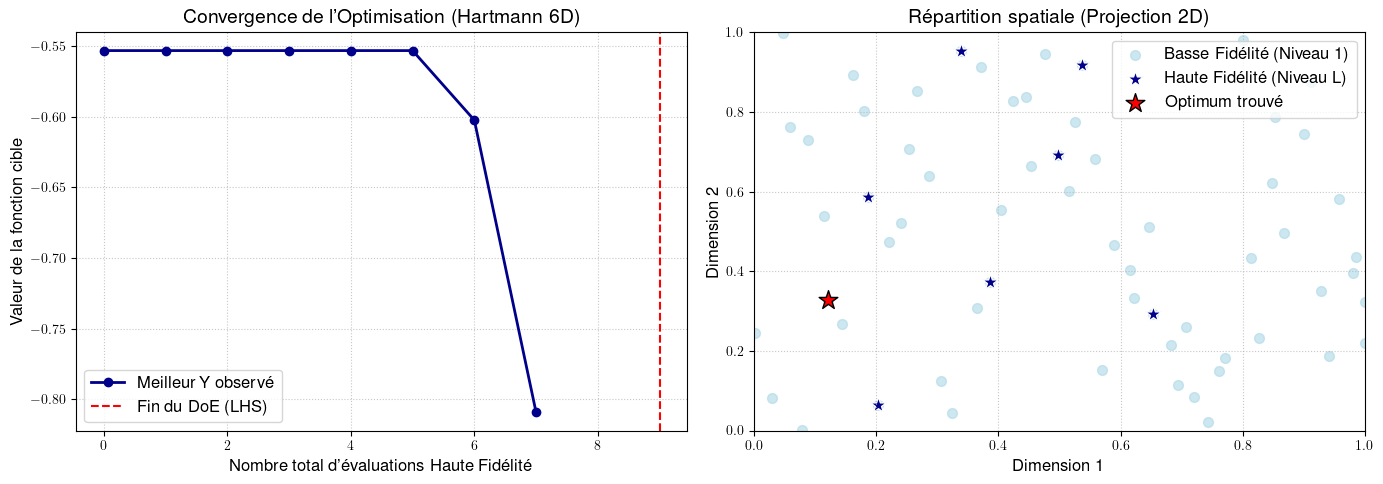

In [31]:



def plot_ego_results(X_train, Y_train, L, n_initial_hf):
    """
    Génère les graphiques d'analyse de l'EGO Multi-Fidélité.
    
    - n_initial_hf : le nombre de points HF générés au départ par le LHS (ex: 10)
    """
    # Récupération des valeurs de Haute Fidélité
    y_hf = Y_train[L]
    
    # np.minimum.accumulate garde en mémoire le meilleur minimum trouvé jusqu'à chaque itération
    best_y = np.minimum.accumulate(y_hf)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- GRAPHIQUE 1 : CONVERGENCE ---
    ax1.plot(best_y, marker='o', linestyle='-', color='darkblue', linewidth=2, label='Meilleur Y observé')
    ax1.axvline(x=n_initial_hf - 1, color='red', linestyle='--', label='Fin du DoE (LHS)')
    
    ax1.set_xlabel("Nombre total d'évaluations Haute Fidélité")
    ax1.set_ylabel("Valeur de la fonction cible")
    ax1.set_title("Convergence de l'Optimisation (Hartmann 6D)")
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.legend()
    
    # --- GRAPHIQUE 2 : PROJECTION 2D DES POINTS ---
    # On trace les dimensions 0 et 1 (les deux premières composantes du vecteur x)
    dim_a, dim_b = 0, 1 
    
    # Points Basse Fidélité (l=1)
    ax2.scatter(X_train[1][:, dim_a], X_train[1][:, dim_b], 
                color='lightblue', s=50, alpha=0.6, label='Basse Fidélité (Niveau 1)')
    
    # Points Haute Fidélité (l=L)
    ax2.scatter(X_train[L][:, dim_a], X_train[L][:, dim_b], 
                color='darkblue', marker='*', s=150, edgecolor='white', label='Haute Fidélité (Niveau L)')
    
    # Mise en évidence du MEILLEUR point HF final
    best_idx = np.argmin(Y_train[L])
    ax2.scatter(X_train[L][best_idx, dim_a], X_train[L][best_idx, dim_b], 
                color='red', marker='*', s=200, edgecolor='black', label='Optimum trouvé')

    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.set_xlabel(f"Dimension {dim_a + 1}")
    ax2.set_ylabel(f"Dimension {dim_b + 1}")
    ax2.set_title("Répartition spatiale (Projection 2D)")
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# --- APPEL DE LA FONCTION ---
# En supposant que vous aviez 10 points HF dans votre LHS initial
plot_ego_results(X_train_final, Y_train_final, L=3, n_initial_hf=10)